<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FML_pr5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Random State : 10
Accuracy     : 0.7906
Precision    : 0.6502
Recall       : 0.4572
F1 Score     : 0.5369
Random State : 20
Accuracy     : 0.8034
Precision    : 0.6816
Recall       : 0.4866
F1 Score     : 0.5679
Random State : 30
Accuracy     : 0.7906
Precision    : 0.6458
Recall       : 0.4679
F1 Score     : 0.5426
Random State : 40
Accuracy     : 0.8013
Precision    : 0.6691
Recall       : 0.4973
F1 Score     : 0.5706
Random State : 42
Accuracy     : 0.7935
Precision    : 0.6509
Recall       : 0.4786
F1 Score     : 0.5516
Random State : 50
Accuracy     : 0.7835
Precision    : 0.6353
Recall       : 0.4332
F1 Score     : 0.5151

Best Random State : 20
Best Accuracy     : 0.8034

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.49      0.57       374

    accuracy                         

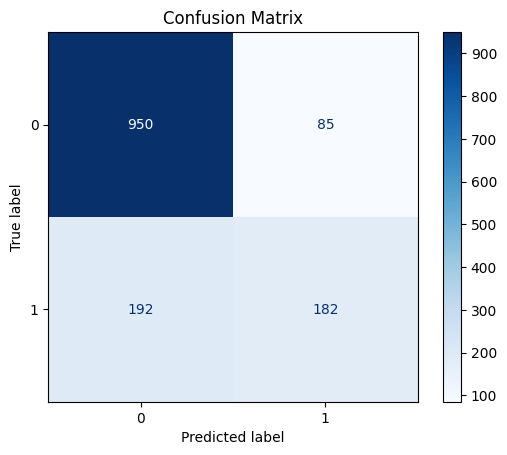


Prediction : Customer Will Stay


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Upload dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Remove CustomerID if present
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df.fillna(df.mode().iloc[0], inplace=True)

# Encode categorical columns
encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column].astype(str))
        encoders[column] = le

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Random states to compare
random_states = [10, 20, 30, 40, 42, 50]

best_accuracy = 0
best_model = None
best_state = None
best_y_test = None
best_y_pred = None

# Train models
for rs in random_states:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=rs,
        stratify=y
    )

    model = SVC(kernel="rbf")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("=" * 40)
    print("Random State :", rs)
    print("Accuracy     :", round(accuracy, 4))
    print("Precision    :", round(precision, 4))
    print("Recall       :", round(recall, 4))
    print("F1 Score     :", round(f1, 4))

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_state = rs
        best_y_test = y_test
        best_y_pred = y_pred

print("\n===================================")
print("Best Random State :", best_state)
print("Best Accuracy     :", round(best_accuracy, 4))
print("===================================")

print("\nClassification Report\n")
print(classification_report(best_y_test, best_y_pred))

# Confusion Matrix
cm = confusion_matrix(best_y_test, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Predict a new customer
# -----------------------------

# Use an existing customer as an example
sample_customer = X[0].reshape(1, -1)

prediction = best_model.predict(sample_customer)

if prediction[0] == 1:
    print("\nPrediction : Customer Will Churn")
else:
    print("\nPrediction : Customer Will Stay")